## import libary

In [105]:
import numpy as np 
import pandas as pd
from spellchecker import SpellChecker
from transformers import BertTokenizer, BertForMaskedLM
import torch
from itertools import product

In [106]:
df = pd.read_csv('data/data.csv')
df.head()

,AnimalName,symptoms1,symptoms2,symptoms3,symptoms4,symptoms5,Dangerous
0,Dog,Fever,Diarrhea,Vomiting,Weight loss,Dehydration,Yes
1,Dog,Fever,Diarrhea,Coughing,Tiredness,Pains,Yes
2,Dog,Fever,Diarrhea,Coughing,Vomiting,Anorexia,Yes
3,Dog,Fever,Difficulty breathing,Coughing,Lethargy,Sneezing,Yes
4,Dog,Fever,Diarrhea,Coughing,Lethargy,Blue Eye,Yes


In [107]:
df.isnull().sum()

AnimalName    0
symptoms1     0
symptoms2     0
symptoms3     0
symptoms4     0
symptoms5     0
Dangerous     2
dtype: int64

In [108]:
df.iloc[:, 0].unique()

array(['Dog', 'cat', 'Rabbit', 'cow', 'chicken', 'cattle', 'mammal',
       'Cattle', 'Horse', 'Turtle', 'Hamster', 'Lion', 'Fox', 'Fox ',
       'Goat', 'Deer', 'Chicken', 'Monkey', 'Birds', 'Sheep', 'Pigs',
       'Fowl', 'Duck', 'Other Birds', 'snake', 'horse', 'duck', 'donkey',
       'Donkey', 'mules', 'Elephant', 'Elk', 'Wapiti', 'Mule deer',
       'Black-tailed deer', 'Sika deer', 'White-tailed deer', 'Reindeer',
       'Moos', 'Tiger', 'Goats', 'Buffaloes', 'Dogs', 'Wolves', 'Hyaenas',
       'Pig'], dtype=object)

In [109]:
spell = SpellChecker()
tokenizer = BertTokenizer.from_pretrained("dmis-lab/biobert-large-cased-v1.1")
model = BertForMaskedLM.from_pretrained("dmis-lab/biobert-large-cased-v1.1")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def correct_phrase(phrase, context="The animal is diagnosed with the symptom"):
    global model
    model = model.to(device)
    words = phrase.split()
    misspelled_words = [word for word in words if word.lower() not in spell]

    if not misspelled_words:
        return phrase  # If there are no misspelled words, return the original phrase

    # Create a dictionary of candidates for the misspelled words
    candidates_dict = {}
    for word in misspelled_words:
        candidates = spell.candidates(word)
        if candidates is None:
            candidates_dict[word] = [word]  # If no candidates, use the word itself
        else:
            candidates_dict[word] = list(candidates)  # Ensure candidates are a list

    # Filter function for candidates (currently just returns them as is)
    def filter_candidates(candidates):
        return candidates

    filtered_candidates_dict = {word: filter_candidates(candidates) for word, candidates in candidates_dict.items()}

    # Build a sentence template with placeholders for the misspelled words
    sentence_template = " ".join([word if word.lower() not in misspelled_words else '{}' for word in words])

    def evaluate_combination(candidate_combination):
        sentence = sentence_template
        for i, candidate in enumerate(candidate_combination):
            sentence = sentence.replace("{}", candidate, 1)

        # Use the context here for evaluation
        evaluation_sentence = f"{context} {sentence}"

        # Tokenize the sentence and feed it into the model
        inputs = tokenizer(evaluation_sentence, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = model(**inputs)
        logits = outputs.logits

        # Evaluate the score for the candidate combination
        score = 0
        for i, candidate in enumerate(candidate_combination):
            candidate_tokens = tokenizer.tokenize(candidate)
            candidate_ids = tokenizer.convert_tokens_to_ids(candidate_tokens)

            for candidate_id in candidate_ids:
                mask_indices = torch.where(inputs["input_ids"] == candidate_id)[1]
                for mask_index in mask_indices:
                    score += logits[0, mask_index, candidate_id].item()

        return sentence, score

    # Generate candidate combinations and evaluate them
    candidate_combinations = list(product(*filtered_candidates_dict.values()))

    if not candidate_combinations:
        return phrase

    scored_combinations = [
        evaluate_combination(combination) for combination in candidate_combinations
    ]
    
    # Rank the combinations based on the evaluation score
    ranked_combinations = sorted(scored_combinations, key=lambda x: x[1], reverse=True)

    best_sentence, best_score = ranked_combinations[0]
    return best_sentence  # Return the corrected sentence without context

# Example usage
corrected_phrase = correct_phrase("thigk skin")
print(f"Corrected phrase: {corrected_phrase}")

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie bert.embeddings.word_embeddings.weight to cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie cls.predictions.bias to cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BertForMaskedLM LOAD REPORT from: dmis-lab/biobert-large-cased-v1.1
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.weight    | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture

Corrected phrase: thick skin


In [110]:
df['symptoms1'].head()

0    Fever
1    Fever
2    Fever
3    Fever
4    Fever
Name: symptoms1, dtype: object

In [111]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from transformers import AutoTokenizer, AutoModel

In [112]:
tokenizer = AutoTokenizer.from_pretrained("dmis-lab/biobert-base-cased-v1.2")
model = AutoModel.from_pretrained("dmis-lab/biobert-base-cased-v1.2")

columns_to_process = df.iloc[:, 1:6]
unique_symptoms = pd.unique(columns_to_process.values.ravel())
unique_symptoms = [symptom for symptom in unique_symptoms if str(symptom) != "nan"]

def get_embeddings(text_list):
    inputs = tokenizer(text_list, return_tensors="pt", padding=True, truncation=True, max_length=128)
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.last_hidden_state[:, 0, :].numpy()

embeddings = get_embeddings(unique_symptoms)

cosine_sim = cosine_similarity(embeddings)

threshold = 0.9

clusters = []
visited = set()

for i, symptom in enumerate(unique_symptoms):
    if i not in visited:
        cluster = [symptom]
        visited.add(i)
        for j, sim in enumerate(cosine_sim[i]):
            if sim >= threshold and j != i and j not in visited:
                cluster.append(unique_symptoms[j])
                visited.add(j)
        clusters.append(cluster)

clustered_data = pd.DataFrame({
    "symptom": [item for sublist in clusters for item in sublist],
    "cluster": [i for i, sublist in enumerate(clusters) for _ in sublist]
})

symptom_to_cluster = dict(zip(clustered_data['symptom'], clustered_data['cluster']))

df_updated = df.copy()

for col in range(1, 6):
    df_updated.iloc[:, col] = df_updated.iloc[:, col].map(symptom_to_cluster)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [113]:
df_updated.head()

,AnimalName,symptoms1,symptoms2,symptoms3,symptoms4,symptoms5,Dangerous
0,Dog,0,1,0,1,1,Yes
1,Dog,0,1,0,1,2,Yes
2,Dog,0,1,0,0,1,Yes
3,Dog,0,3,0,1,0,Yes
4,Dog,0,1,0,1,4,Yes


In [114]:
birds = ['chicken', 'fowl', 'duck', 'other birds', 'birds']
deers = ['deer', 'mule deer', 'black-tailed deer', 'sika deer', 'white-tailed deer', 'reindeer', 'wapiti', 'elk']

df_updated['AnimalName'] = df_updated['AnimalName'].str.lower()

df_updated['AnimalName'] = df_updated['AnimalName'].apply(
    lambda x: 'bird' if any(bird in x for bird in birds) else 
              ('deer' if any(deer in x for deer in deers) else x)
)

In [115]:
df_updated['AnimalName'].unique()

array(['dog', 'cat', 'rabbit', 'cow', 'bird', 'cattle', 'mammal', 'horse',
       'turtle', 'hamster', 'lion', 'fox', 'fox ', 'goat', 'deer',
       'monkey', 'sheep', 'pigs', 'snake', 'donkey', 'mules', 'elephant',
       'moos', 'tiger', 'goats', 'buffaloes', 'dogs', 'wolves', 'hyaenas',
       'pig'], dtype=object)

In [116]:
df_topred = df_updated[df_updated.isna().any(axis=1)]
df_updated = df_updated.dropna()

In [117]:
df_topred.head()

,AnimalName,symptoms1,symptoms2,symptoms3,symptoms4,symptoms5,Dangerous
269,sheep,4,0,1,1,1,NaN
695,buffaloes,4,0,1,1,1,NaN


In [118]:
df_updated['Dangerous'] = df_updated['Dangerous'].str.strip().str.lower()
df_updated['Dangerous'] = df_updated['Dangerous'].map({'yes': 1, 'no': 0})

In [119]:
df_updated = pd.get_dummies(df_updated, columns=['AnimalName'])
object_columns = df_updated.select_dtypes(include=['object']).columns
df_updated[object_columns] = df_updated[object_columns].apply(pd.to_numeric, errors='coerce')
df_updated.head()

,symptoms1,symptoms2,symptoms3,symptoms4,symptoms5,Dangerous,AnimalName_bird,AnimalName_buffaloes,AnimalName_cat,AnimalName_cattle,...,AnimalName_moos,AnimalName_mules,AnimalName_pig,AnimalName_pigs,AnimalName_rabbit,AnimalName_sheep,AnimalName_snake,AnimalName_tiger,AnimalName_turtle,AnimalName_wolves
0,0,1,0,1,1,1,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,0,1,0,1,2,1,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,0,1,0,0,1,1,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,0,3,0,1,0,1,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,0,1,0,1,4,1,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [120]:
X = df_updated.drop(columns = ['Dangerous'])
y = df_updated['Dangerous']

In [121]:
from imblearn.over_sampling import SVMSMOTE

svm_smote = SVMSMOTE(sampling_strategy='auto', random_state=42)

print("Category value distribution before SVMSMOTE:")
print(y.value_counts())

X, y = svm_smote.fit_resample(X, y)

print("\nCategory value distribution after SVMSMOTE:")
print(pd.Series(y).value_counts())

Category value distribution before SVMSMOTE:
Dangerous
1    849
0     20
Name: count, dtype: int64

Category value distribution after SVMSMOTE:
Dangerous
1    849
0    476
Name: count, dtype: int64


In [122]:
from sklearn.model_selection import StratifiedShuffleSplit

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_index, test_index in sss.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

In [123]:
X_train.head()

,symptoms1,symptoms2,symptoms3,symptoms4,symptoms5,AnimalName_bird,AnimalName_buffaloes,AnimalName_cat,AnimalName_cattle,AnimalName_cow,...,AnimalName_moos,AnimalName_mules,AnimalName_pig,AnimalName_pigs,AnimalName_rabbit,AnimalName_sheep,AnimalName_snake,AnimalName_tiger,AnimalName_turtle,AnimalName_wolves
260,5,5,4,1,12,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
492,0,2,1,2,0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
335,1,3,1,1,0,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
686,0,10,0,3,0,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1060,0,1,0,3,0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


[I 2026-03-11 22:22:58,834] A new study created in memory with name: LGBM_CPU_Fast
[I 2026-03-11 22:22:59,206] Trial 0 finished with value: 0.9829627829892282 and parameters: {'num_leaves': 123, 'max_depth': 4, 'learning_rate': 0.021593327465625412, 'n_estimators': 432, 'min_child_samples': 18, 'subsample': 0.689622320473647, 'colsample_bytree': 0.5907752831049053}. Best is trial 0 with value: 0.9829627829892282.
[I 2026-03-11 22:23:00,063] Trial 1 finished with value: 0.9408813652591506 and parameters: {'num_leaves': 112, 'max_depth': 8, 'learning_rate': 0.0012746355794064535, 'n_estimators': 970, 'min_child_samples': 37, 'subsample': 0.8961796214299611, 'colsample_bytree': 0.614317286999126}. Best is trial 0 with value: 0.9829627829892282.
[I 2026-03-11 22:23:00,402] Trial 2 finished with value: 0.946138025142865 and parameters: {'num_leaves': 119, 'max_depth': 10, 'learning_rate': 0.0006894478121657978, 'n_estimators': 314, 'min_child_samples': 28, 'subsample': 0.9747707084976798, '

Best Params: {'num_leaves': 43, 'max_depth': 7, 'learning_rate': 0.031298987990164236, 'n_estimators': 890, 'min_child_samples': 5, 'subsample': 0.8625269809524778, 'colsample_bytree': 0.8401427897978934}
              precision    recall  f1-score   support

           0       0.97      0.98      0.97        95
           1       0.99      0.98      0.99       170

    accuracy                           0.98       265
   macro avg       0.98      0.98      0.98       265
weighted avg       0.98      0.98      0.98       265



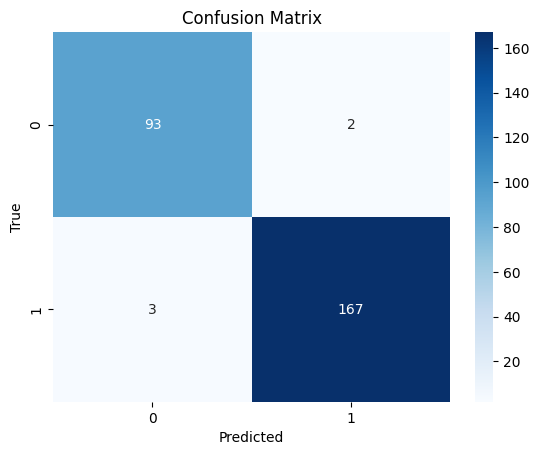

In [124]:
import optuna
import lightgbm as lgb
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def objective(trial):
    params = {
        'objective': 'binary',
        'metric': 'binary_error',
        'boosting_type': 'gbdt',
        # ❌ เอา 'device': 'gpu' ออกไปเลยครับ งานนี้ CPU เร็วกว่า
        # ✅ ใช้ n_jobs=-1 เพื่อให้ดึงขุมพลัง CPU ทุก Core มาช่วยกันรันแทน
        'n_jobs': -1, 
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 1e-4, 0.1, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'subsample': trial.suggest_float('subsample', 0.5, 1),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1),
        'verbose': -1,
        'random_state': 42
    }

    model = lgb.LGBMClassifier(**params)

    # ลดเหลือ 3 Folds ก่อนเพื่อทดสอบความเร็ว (ถ้าเร็วพอค่อยปรับเป็น 5 เหมือนเดิม)
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    auc_scores = []
    
    for fold, (train_idx, valid_idx) in enumerate(skf.split(X_train, y_train)):
        # พิมพ์บอกสถานะให้รู้ว่าไม่ค้าง
        # print(f"    -> รัน Trial {trial.number} | Fold {fold+1}...") 
        
        X_train_fold, X_valid_fold = X_train.iloc[train_idx], X_train.iloc[valid_idx]
        y_train_fold, y_valid_fold = y_train.iloc[train_idx], y_train.iloc[valid_idx]

        model.fit(X_train_fold, y_train_fold)
        y_pred_prob = model.predict_proba(X_valid_fold)[:, 1]  

        auc = roc_auc_score(y_valid_fold, y_pred_prob)
        auc_scores.append(auc)

    return np.mean(auc_scores) 

# รัน Study ใหม่
study = optuna.create_study(direction='maximize', study_name="LGBM_CPU_Fast")
study.optimize(objective, n_trials=30) # รัน 30 รอบด้วย CPU แป๊บเดียวก็เสร็จครับ

# ดูผลลัพธ์พารามิเตอร์ที่ดีที่สุด
best_params = study.best_params
print("Best Params:", best_params)

# เทรนโมเดลด้วยพารามิเตอร์ที่ดีที่สุด
model = lgb.LGBMClassifier(**best_params, random_state=42, verbose=-1, n_jobs=-1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['0', '1'], yticklabels=['0', '1'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [125]:
df_topred = df_topred.iloc[:, :-1]
df_topred = pd.get_dummies(df_topred, columns=['AnimalName'], drop_first=True)
object_columns = df_topred.select_dtypes(include=['object']).columns
for col in object_columns:
    df_topred[col] = pd.to_numeric(df_topred[col], errors='coerce')
df_topred = df_topred.reindex(columns=X.columns, fill_value=0)

In [126]:
pred = model.predict(df_topred)
pred

array([1, 1])

## save model

In [127]:
import joblib

# ... (โค้ดก่อนหน้านี้ของคุณที่ทำ plt.show() เสร็จแล้ว) ...

# 1. ตั้งชื่อไฟล์โมเดลที่คุณต้องการเซฟ (นามสกุลมักจะใช้ .pkl หรือ .joblib)
model_filename = 'best_lightgbm_model.pkl'

# 2. เซฟโมเดลเก็บไว้ในเครื่อง
joblib.dump(model, model_filename)

print(f"\n✅ บันทึกโมเดลสำเร็จ! ไฟล์ถูกเก็บไว้ที่: {model_filename}")


✅ บันทึกโมเดลสำเร็จ! ไฟล์ถูกเก็บไว้ที่: best_lightgbm_model.pkl


In [128]:
import joblib

# สมมติว่าตัวแปร X (หรือ X_train) คือข้อมูล Features ที่คุณใช้เทรน (ที่แปลง Dummy แล้ว)
joblib.dump(list(X_train.columns), 'model_columns.pkl')

print("เซฟรายชื่อคอลัมน์สำเร็จ! ได้ไฟล์ model_columns.pkl แล้ว")

เซฟรายชื่อคอลัมน์สำเร็จ! ได้ไฟล์ model_columns.pkl แล้ว


In [129]:
import joblib

# เซฟ Dictionary ที่เก็บค่าแปล อาการ -> ตัวเลข (Cluster ID)
joblib.dump(symptom_to_cluster, 'symptom_to_cluster.pkl')

print("✅ บันทึกคู่มือแปลอาการสำเร็จ! ได้ไฟล์ symptom_to_cluster.pkl")

✅ บันทึกคู่มือแปลอาการสำเร็จ! ได้ไฟล์ symptom_to_cluster.pkl
